# **Retail Sales Intelligence & Business Performance Analytics**

# *Project Summary*

This Data Analytics project focuses on analyzing retail sales data to understand sales performance, profitability, customer segments, product categories, regional trends, shipping patterns, and the impact of discounts. The project uses data cleaning, exploratory data analysis (EDA), statistical analysis, and interactive data visualization to identify important business patterns and generate actionable insights. In addition, sales prediction is included to estimate future sales based on historical retail transaction patterns, supporting better business planning and decision-making.

#*Project Objectives*

* Analyze overall sales and profit performance of the retail business.
* Identify the best- and worst-performing product categories and sub-categories.
Analyze sales and profit trends across different regions, states, and cities.
* Understand purchasing behavior across different customer segments.
* Examine the relationship between sales, quantity, discount, and profit.
* Identify products and customers contributing significantly to overall sales.
* Analyze different shipping modes and their distribution.
* Discover trends in sales over time.
* Identify areas of high profitability and potential business losses.
* Create meaningful visualizations to support data-driven business decisions.
* Use historical sales information to develop a sales prediction model for future estimation.

# *Dataset Description*

The project uses a retail sales transaction dataset containing 9,994 records and 21 attributes. Each row represents a retail order or product transaction and contains information about orders, customers, products, locations, shipping, sales, quantity, discount, and profit. The dataset covers different customer segments, product categories and sub-categories, and geographical regions, making it suitable for comprehensive retail performance analysis and sales prediction.

# *The Dataset Includes the Following Key Attributes:*

* Row ID – Unique identifier for each record.
* Order ID – Unique identifier of the customer order.
* Order Date – Date on which the order was placed.
* Ship Date – Date on which the order was shipped.
* Ship Mode – Shipping method used for the order.
* Customer ID – Unique customer identifier.
* Customer Name – Name of the customer.
* Segment – Customer segment such as Consumer, Corporate, etc.
* Country – Country of the customer/order.
* City – City where the order was placed.
* State – State associated with the order.
* Postal Code – Postal code of the location.
* Region – Geographical region of the order.
* Product ID – Unique identifier of the product.
* Category – Main product category.
* Sub-Category – Specific product sub-category.
* Product Name – Name of the product.
* Sales – Revenue generated from the transaction.
* Quantity – Number of products purchased.
* Discount – Discount applied to the transaction.
* Profit – Profit or loss generated from the transaction.



# IMPORTING LIBRARIES

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.cluster import KMeans

import os
import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
import joblib

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("[info] xgboost not installed -> that model will be skipped (pip install xgboost to enable)")

In [3]:
data=pd.read_csv("/content/drive/MyDrive/End-to-End Retail Sales Analysis & Sales Prediction/Retail Sales.csv/sales data.csv", encoding='latin1')
data

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2011-110422,22-01-2011,24-01-2011,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2014-121258,27-02-2014,04-03-2014,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2014-121258,27-02-2014,04-03-2014,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2014-121258,27-02-2014,04-03-2014,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [4]:
df = data.copy()

##  BASIC DATA EXPLORATION

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2011-110422,22-01-2011,24-01-2011,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2014-121258,27-02-2014,04-03-2014,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2014-121258,27-02-2014,04-03-2014,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2014-121258,27-02-2014,04-03-2014,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2014-119914,05-05-2014,10-05-2014,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [7]:
df.shape

(9994, 21)

In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [10]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Convert Date Columns

In [11]:
# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], format='%d-%m-%Y')
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format='%d-%m-%Y')

# Year and Month
df["Year"] = df["Order Date"].dt.year
df["Month Number"] = df["Order Date"].dt.month
df["Month"] = df["Order Date"].dt.strftime("%B")
# # Create Month and Year columns
# df["Month"] = df["Order Date"].dt.month_name()
# df["Year"] = df["Order Date"].dt.year
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month Number,Month
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2013,11,November
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2013,11,November
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2013,6,June
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2012,10,October
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2012,10,October
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2011-110422,2011-01-22,2011-01-24,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,2011,1,January
9990,9991,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,2014,2,February
9991,9992,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,2014,2,February
9992,9993,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,2014,2,February


## **Exploratory Data Analysis & Visualization**

Exploratory Data Analysis (EDA) is the process of analyzing and visualizing a dataset to understand its structure, identify patterns, detect anomalies, and extract meaningful insights before building machine learning models. It helps in understanding the distribution of data, relationships between variables, trends, and business performance through statistical summaries and visualizations.

1. Monthly Sales Trend

In [12]:
monthly_sales = (
    df.groupby(
        ["Month Number", "Month"],
        as_index=False
    )["Sales"]
    .sum()
    .sort_values("Month Number")
)

fig = px.line(
    monthly_sales,
    x="Month",
    y="Sales",
    markers=True,
    title="Monthly Sales Trend"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Total Sales"
)

fig.show()

Analysis

* Sales fluctuate considerably across different months.
* November and December record the highest sales, while February has the lowest sales.
* Sales increase strongly during the later months of the year.
* September also shows a significant increase compared with several earlier months.
* This indicates a clear seasonal pattern in retail sales.

Business Insights

* Increase inventory before the November–December peak season.
* Plan promotional campaigns around high-demand periods.
* February can be targeted with special offers to improve sales.
* Use seasonal demand patterns for better inventory and workforce planning.
* Sales forecasting should consider monthly seasonality.

### 2. *Monthly Profit Trend*

In [13]:
monthly_profit = (
    df.groupby(
        ["Month Number", "Month"],
        as_index=False
    )["Profit"]
    .sum()
    .sort_values("Month Number")
)

fig = px.line(
    monthly_profit,
    x="Month",
    y="Profit",
    markers=True,
    title="Monthly Profit Trend"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Total Profit"
)

fig.show()

Analysis

* Monthly profit follows a generally positive relationship with sales, but the pattern is not identical.
* December records the highest profit, while January has relatively low profit.
* Some months generate good sales but comparatively lower profit.
* Profit varies because of factors such as discounts, product mix, and operating costs.
* The later months generally contribute strongly to overall profitability.

Business Insights

* Focus on high-profit months to maximize business returns.
* Investigate months where sales are high but profit is relatively low.
* Control excessive discounting during high-demand periods.
* Promote products with stronger profit margins.
* Use monthly profit trends for budgeting and financial planning.

## 3.Yearly Sales Trend by Category

In [14]:
yearly_category_sales = (
    df.groupby(
        ["Year", "Category"],
        as_index=False
    )["Sales"]
    .sum()
)

fig = px.area(
    yearly_category_sales,
    x="Year",
    y="Sales",
    color="Category",
    markers=True,
    title="Yearly Sales Trend by Category"
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Total Sales"
)

fig.show()

Analysis

* Sales generally increase across the years for all three categories.
* Technology shows the strongest overall sales performance.
* Sales increased substantially by 2014, especially for Technology and Office Supplies.
* Furniture also shows steady growth over the period.
* The increasing trend indicates overall expansion in retail sales.
* Business Insights
Increase investment in Technology products, which generate the highest sales.
* Maintain sufficient inventory for consistently growing categories.
* Identify the reasons behind the strong growth in Technology.
* Use historical category trends for future sales forecasting.
* Develop separate strategies for each product category based on its growth pattern.

## 4. Sales Share by Category

In [15]:
category_sales = (
    df.groupby(
        "Category",
        as_index=False
    )["Sales"]
    .sum()
)

fig = px.pie(
    category_sales,
    names="Category",
    values="Sales",
    title="Sales Share by Category"
)

fig.show()

Analysis

* Technology contributes the largest share of total sales.
* Furniture contributes the second-largest share.
* Office Supplies has the smallest share among the three categories.
* The sales contribution is relatively distributed rather than being dominated by a single category.
* Technology is therefore an important driver of overall revenue.

Business Insights

* Prioritize high-performing Technology products.
* Maintain a balanced product portfolio to reduce dependency on one category.
* Analyze low-performing categories for opportunities to improve sales.
* Use category-level sales contribution when planning inventory.
* Allocate marketing resources according to category performance.

### 5. Sales Share by Segment

In [16]:
segment_sales = (
    df.groupby(
        "Segment",
        as_index=False
    )["Sales"]
    .sum()
)

fig = px.pie(
    segment_sales,
    names="Segment",
    values="Sales",
    title="Sales Share by Segment"
)

fig.show()

Analysis

* The Consumer segment generates the highest sales.
* Corporate contributes the second-highest sales.
* Home Office has the lowest sales contribution.
* Consumer customers represent a major source of overall revenue.
*  The segment distribution indicates different levels of purchasing activity among customer groups.

Business Insights

* Focus customer-retention strategies on the Consumer segment.
* Develop targeted promotions for Corporate and Home Office customers.
* Investigate the purchasing behavior of high-value customers in each segment.
* Introduce customized offers based on customer segment.
* Explore opportunities to increase Home Office sales.

## 6. Orders by Ship Mode

In [17]:
ship_mode_orders = (
    df.groupby("Ship Mode")["Order ID"]
    .nunique()
    .reset_index(name="Orders")
)

fig = px.pie(
    ship_mode_orders,
    names="Ship Mode",
    values="Orders",
    hole=0.5,
    title="Orders by Ship Mode"
)

fig.show()

Analysis

* Standard Class is the most frequently used shipping mode.
* Second Class is the next most commonly used option.
* First Class has fewer orders compared with Standard and Second Class.
* Same Day has the lowest number of orders.
* Customers appear to prefer standard and relatively economical shipping options.

Business Insights

* Ensure sufficient logistics capacity for Standard Class orders.
* Maintain reliable delivery performance for the most-used shipping method.
* Analyze whether faster shipping options can be promoted profitably.
* Same Day delivery can be targeted toward customers willing to pay for speed.
* Monitor shipping performance to improve customer satisfaction.


## 7. Sales Distribution by Category



In [18]:
fig = px.histogram(
    df,
    x="Sales",
    color="Category",
    nbins=40,
    title="Sales Distribution by Category"
)

fig.update_layout(
    xaxis_title="Sales",
    yaxis_title="Number of Orders"
)

fig.show()

Analysis

* Most transactions are concentrated in the lower sales-value range.
* The distribution is strongly right-skewed, with a small number of very high-value transactions.
* Technology, Furniture, and Office Supplies show different sales-value patterns.
* A few transactions contribute exceptionally high sales values.
* This indicates substantial variation in transaction size.

Business Insights

* Investigate high-value orders to identify important products and customers.
* Use upselling and cross-selling to increase average order value.
* Create product bundles to encourage larger purchases.
* Monitor high-value transactions for business opportunities and data-quality issues.
* Use median and percentile measures in addition to the average when analyzing sales.


## 8. Discount Distribution by Category

In [19]:
fig = px.histogram(
    df,
    x="Discount",
    color="Category",
    nbins=40,
    title="Discount Distribution by Category"
)

fig.update_layout(
    xaxis_title="Discount",
    yaxis_title="Number of Orders"
)

fig.show()

Analysis

* Discounts are concentrated around commonly used discount levels, particularly 0% and 20%.
* Discount levels vary across product categories.
* Some transactions receive relatively high discounts.
* Excessive discounting can potentially reduce profitability.
* The distribution indicates that discounting is an important factor in the retail sales strategy.

Business Insights

* Avoid unnecessary high discounts that reduce profit margins.
* Identify products where discounts successfully increase sales.
* Use targeted discounts instead of applying large discounts broadly.
* Analyze the relationship between discount and profit before setting promotions.
* Establish category-specific discount strategies.

## 9. Average Profit by Category



In [20]:
avg_profit_category = (
    df.groupby("Category", as_index=False)["Profit"]
    .mean()
    .sort_values("Profit", ascending=False)
)

fig = px.bar(
    avg_profit_category,
    x="Category",
    y="Profit",
    text_auto=".2f",
    title="Average Profit by Category"
)

fig.update_layout(
    xaxis_title="Category",
    yaxis_title="Average Profit"
)

fig.show()

Analysis

* Technology has the highest average profit per transaction.
* Office Supplies generates a moderate average profit.
* Furniture has the lowest average profit among the three categories.
* The difference indicates that sales volume alone does not determine profitability.
* Technology is both a strong sales contributor and a high-profit category.

Business Insights

* Give greater strategic attention to Technology products.
* Review Furniture pricing, discounting, and product costs to improve margins.
* Promote high-margin products to increase overall profitability.
* Avoid evaluating categories based only on sales; consider profit as well.
* Use profit-margin analysis when making product and pricing decisions.

# 10.Category → Sub-Category Sales Breakdown

In [21]:
# Category and Sub-Category wise Sales
sunburst_data = (
    df.groupby(
        ["Category", "Sub-Category"],
        as_index=False
    )["Sales"]
    .sum()
)

# Sunburst chart
fig = px.sunburst(
    sunburst_data,
    path=["Category", "Sub-Category"],
    values="Sales",
    title="Category → Sub-Category Sales Breakdown"
)

fig.show()

Analysis

* Phones are the highest-selling sub-category in the dataset.
* Chairs are another major contributor to total sales.
* Storage, Tables, and Binders also contribute significantly.
* Sales performance varies considerably among sub-categories.
* Technology contains several strong-performing sub-categories.

Business Insights

* Maintain adequate inventory for high-performing sub-categories such as Phones and Chairs.
* Promote complementary products around popular sub-categories.
* Identify weak sub-categories and evaluate whether pricing or marketing improvements are required.
* Use sub-category performance to optimize product assortment.
* Develop targeted promotions for high-potential products.

## 11.Region → State Sales Breakdown

In [22]:
region_state_sales = (
    df.groupby(
        ["Region", "State"],
        as_index=False
    )["Sales"]
    .sum()
)

fig = px.treemap(
    region_state_sales,
    path=["Region", "State"],
    values="Sales",
    title="Region → State Sales Breakdown"
)

fig.show()

Analysis

* The West region has the highest overall sales.
* The East region is the second-highest contributor.
* Central and South contribute comparatively lower sales.
* California is the strongest individual state by sales.
* Sales performance varies significantly across states and regions.

Business Insights

* Prioritize inventory and marketing in high-performing regions.
* Investigate successful sales strategies used in the West region.
* Develop targeted campaigns for lower-performing regions.
* Focus on high-performing states such as California and New York for expansion opportunities.
* Use geographical sales patterns to optimize distribution and logistics.

# *Outlier Detection*

Outlier Detection is the process of identifying data points that are significantly different from the rest of the dataset. Outliers can occur due to data entry errors, measurement errors, or genuine business events. Detecting outliers helps improve data quality and ensures a better understanding of the dataset before analysis and machine learning.

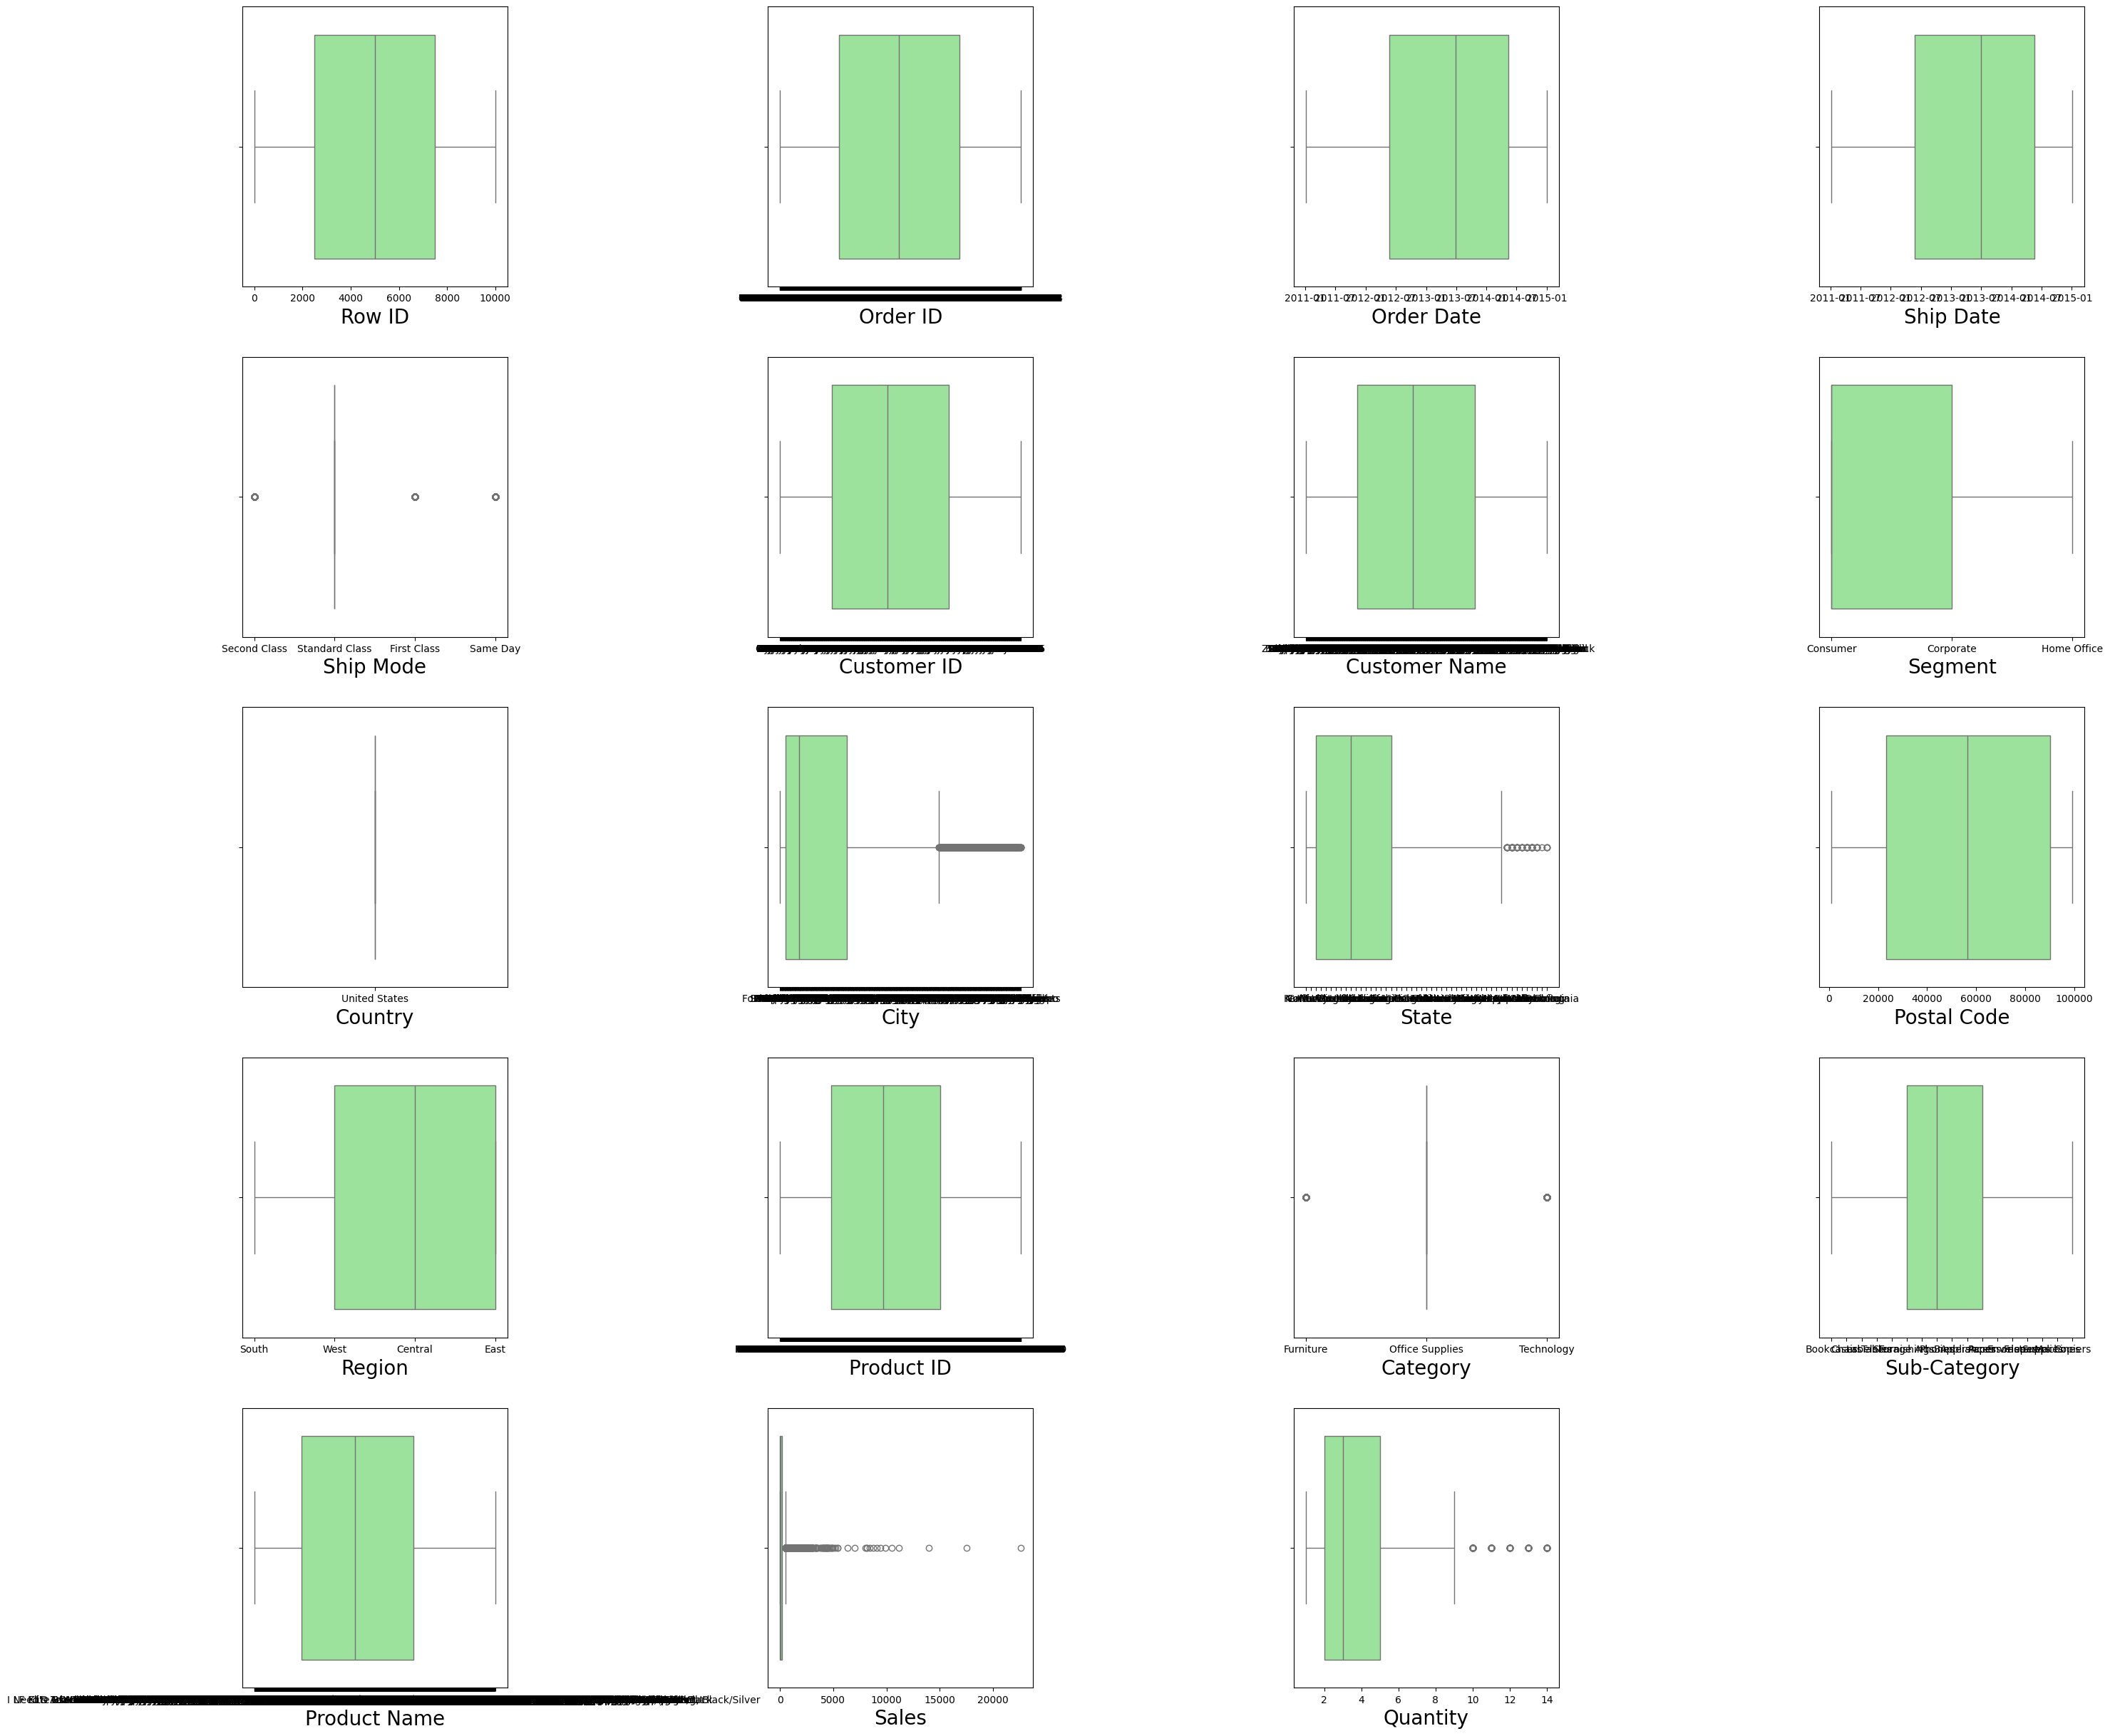

In [23]:
plt.figure(figsize=(30,25), facecolor="white")

plotnumber = 1

for column in df.columns[:19]:                                                                                      # 5 rows ,  4 columns
    plt.subplot(5,4, plotnumber)
    sns.boxplot(x=df[column], color="lightgreen")
    plt.xlabel(column, fontsize=20)
    # plt.title(column, fontsize=14)
    plotnumber += 1

plt.tight_layout(pad=3.0)
plt.show()

In [24]:
def remove_outliers_iqr(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    cleaned = data[(data[column] > lower) & (data[column] < upper)]
    print(f"  {column}: {len(data)} -> {len(cleaned)} rows after removing outliers")
    return cleaned

df = df.copy()
for col in ["Quantity", "Discount", "Profit"]:
    df = remove_outliers_iqr(df, col)

  Quantity: 9994 -> 9824 rows after removing outliers
  Discount: 9824 -> 8914 rows after removing outliers
  Profit: 8914 -> 7480 rows after removing outliers


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7480 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         7480 non-null   int64         
 1   Order ID       7480 non-null   object        
 2   Order Date     7480 non-null   datetime64[ns]
 3   Ship Date      7480 non-null   datetime64[ns]
 4   Ship Mode      7480 non-null   object        
 5   Customer ID    7480 non-null   object        
 6   Customer Name  7480 non-null   object        
 7   Segment        7480 non-null   object        
 8   Country        7480 non-null   object        
 9   City           7480 non-null   object        
 10  State          7480 non-null   object        
 11  Postal Code    7480 non-null   int64         
 12  Region         7480 non-null   object        
 13  Product ID     7480 non-null   object        
 14  Category       7480 non-null   object        
 15  Sub-Category   7480 non-nu

In [26]:
df.nunique()                                        # Number of unique values in each column

,0
Row ID,7480
Order ID,4291
Order Date,1205
Ship Date,1295
Ship Mode,4
Customer ID,789
Customer Name,789
Segment,3
Country,1
City,508


In [27]:
print(df["Category"].unique())

print(df["Region"].unique())

print(df["Ship Mode"].unique())

print(df["Segment"].unique())                                                      # to see unique values

['Furniture' 'Office Supplies' 'Technology']
['South' 'West' 'Central' 'East']
['Second Class' 'Standard Class' 'First Class' 'Same Day']
['Consumer' 'Corporate' 'Home Office']


  *Feature* *Engineering*

* To make data more meaningful.

* To perform time-based analysis.

* To improve visualization.

* To simplify data analysis.

* To support better business decision-making.

In [28]:
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d-%m-%Y", errors="coerce")
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()
print("  Added Year, Month columns")

  Added Year, Month columns


In [29]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month Number,Month
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136,2013,11,November
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714,2013,6,June
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164,2012,10,October
5,6,CA-2011-115812,2011-06-09,2011-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694,2011,6,June
6,7,CA-2011-115812,2011-06-09,2011-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656,2011,6,June
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2011-110422,2011-01-22,2011-01-24,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028,2011,1,January
9990,9991,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332,2014,2,February
9991,9992,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932,2014,2,February
9992,9993,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200,2014,2,February


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7480 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         7480 non-null   int64         
 1   Order ID       7480 non-null   object        
 2   Order Date     7480 non-null   datetime64[ns]
 3   Ship Date      7480 non-null   datetime64[ns]
 4   Ship Mode      7480 non-null   object        
 5   Customer ID    7480 non-null   object        
 6   Customer Name  7480 non-null   object        
 7   Segment        7480 non-null   object        
 8   Country        7480 non-null   object        
 9   City           7480 non-null   object        
 10  State          7480 non-null   object        
 11  Postal Code    7480 non-null   int64         
 12  Region         7480 non-null   object        
 13  Product ID     7480 non-null   object        
 14  Category       7480 non-null   object        
 15  Sub-Category   7480 non-nu

 *KPI CALCULATION*

Key Performance Indicators (KPIs) are measurable metrics used to evaluate the overall performance of a business. KPI calculation helps organizations monitor sales performance, profitability, customer activity, and operational efficiency, enabling data-driven decision-making.

In [31]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
average_sales = df["Sales"].mean()

print(f"  Total Sales      : {total_sales:,.2f}")
print(f"  Total Profit     : {total_profit:,.2f}")
print(f"  Total Orders     : {total_orders}")
print(f"  Total Customers  : {total_customers}")
print(f"  Average Sales    : {average_sales:,.2f}")

  Total Sales      : 758,185.52
  Total Profit     : 107,065.63
  Total Orders     : 4291
  Total Customers  : 789
  Average Sales    : 101.36


*Data* *Cleaning*

In [32]:
df.shape

(7480, 24)

In [33]:
df = df.drop_duplicates()
drop = [c for c in ["Row ID", "Country", "Month_Year"] if c in df.columns]
df = df.drop(columns=drop)
print(f"  Shape after cleaning: {df.shape}")

# keep a copy with readable labels for the chatbot later
df_readable = df.copy()

  Shape after cleaning: (7480, 22)


Label *Encoding*


Label Encoding is a feature encoding technique used to convert categorical data into numerical values by assigning a unique integer to each category. It is commonly used when categorical variables have an inherent order or when machine learning algorithms require numerical input.

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7480 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       7480 non-null   object        
 1   Order Date     7480 non-null   datetime64[ns]
 2   Ship Date      7480 non-null   datetime64[ns]
 3   Ship Mode      7480 non-null   object        
 4   Customer ID    7480 non-null   object        
 5   Customer Name  7480 non-null   object        
 6   Segment        7480 non-null   object        
 7   City           7480 non-null   object        
 8   State          7480 non-null   object        
 9   Postal Code    7480 non-null   int64         
 10  Region         7480 non-null   object        
 11  Product ID     7480 non-null   object        
 12  Category       7480 non-null   object        
 13  Sub-Category   7480 non-null   object        
 14  Product Name   7480 non-null   object        
 15  Sales          7480 non-nu

In [35]:
from sklearn.preprocessing import LabelEncoder

order_id_encoder = LabelEncoder()
ship_mode_encoder = LabelEncoder()
customer_id_encoder = LabelEncoder()
customer_name_encoder = LabelEncoder()                                                    #  12 object into int
segment_encoder = LabelEncoder()
city_encoder = LabelEncoder()
state_encoder = LabelEncoder()
region_encoder = LabelEncoder()
product_id_encoder = LabelEncoder()
category_encoder = LabelEncoder()
sub_category_encoder = LabelEncoder()
product_name_encoder = LabelEncoder()
month_encoder = LabelEncoder()

df['Order ID'] = order_id_encoder.fit_transform(df['Order ID'])
df['Ship Mode'] = ship_mode_encoder.fit_transform(df['Ship Mode'])
df['Customer ID'] = customer_name_encoder.fit_transform(df['Customer ID'])
df['Customer Name'] = customer_name_encoder.fit_transform(df['Customer Name'])
df['Segment'] = segment_encoder.fit_transform(df['Segment'])
df['City'] = city_encoder.fit_transform(df['City'])
df['State'] = state_encoder.fit_transform(df['State'])
df['Region'] = region_encoder.fit_transform(df['Region'])
df['Product ID'] = product_id_encoder.fit_transform(df['Product ID'])
df['Category'] = category_encoder.fit_transform(df['Category'])
df['Sub-Category'] = sub_category_encoder.fit_transform(df['Sub-Category'])
df['Product Name'] = product_name_encoder.fit_transform(df['Product Name'])
df['Month'] = month_encoder.fit_transform(df['Month'])

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7480 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       7480 non-null   int64         
 1   Order Date     7480 non-null   datetime64[ns]
 2   Ship Date      7480 non-null   datetime64[ns]
 3   Ship Mode      7480 non-null   int64         
 4   Customer ID    7480 non-null   int64         
 5   Customer Name  7480 non-null   int64         
 6   Segment        7480 non-null   int64         
 7   City           7480 non-null   int64         
 8   State          7480 non-null   int64         
 9   Postal Code    7480 non-null   int64         
 10  Region         7480 non-null   int64         
 11  Product ID     7480 non-null   int64         
 12  Category       7480 non-null   int64         
 13  Sub-Category   7480 non-null   int64         
 14  Product Name   7480 non-null   int64         
 15  Sales          7480 non-nu

# *Feature Relationship analysis*

Text(0.5, 1.0, 'Correlation Heatmap')

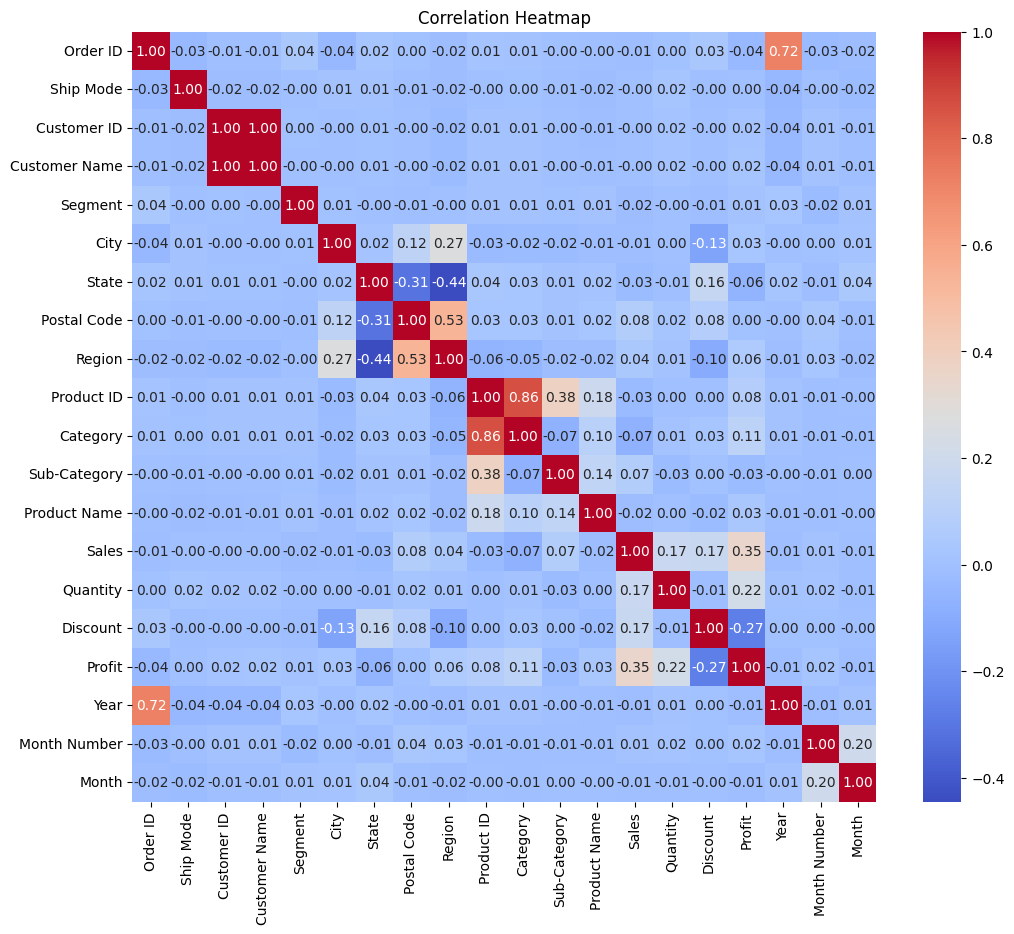

In [37]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")

Analysis

* The correlation heatmap shows the relationships between the dataset's numerical variables.
* Sales and Profit have a positive relationship, indicating that higher sales can generally contribute to higher profit.
* Quantity has a weaker relationship with several financial variables compared with Sales.
* Discount can influence profitability and should be considered when analyzing profit performance.
* The heatmap helps identify variables that may be useful for further analysis and prediction.

In [38]:
# Save the final cleaned dataset
cleaned_file = "Retail_Sales_Cleaned.csv"

df.to_csv(cleaned_file, index=False)

print("Cleaned dataset saved successfully!")
print("File name:", cleaned_file)
print("Shape:", df.shape)

Cleaned dataset saved successfully!
File name: Retail_Sales_Cleaned.csv
Shape: (7480, 22)


In [39]:
from google.colab import files

files.download("Retail_Sales_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# SQL Business Analysis

In [40]:
import sqlite3
import pandas as pd

# Create SQLite database
conn = sqlite3.connect("retail_sales.db")

# Load final cleaned dataset into SQL table
df.to_sql(
    "retail_sales",
    conn,
    if_exists="replace",
    index=False
)

print("Cleaned dataset successfully loaded into SQL!")

Cleaned dataset successfully loaded into SQL!


In [41]:
query = """
SELECT
    COUNT(*) AS total_transactions,
    COUNT(DISTINCT "Order ID") AS total_orders,
    COUNT(DISTINCT "Customer ID") AS total_customers,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit,
    ROUND(AVG(Sales), 2) AS average_sales,
    ROUND(AVG(Profit), 2) AS average_profit,
    ROUND(AVG(Discount), 2) AS average_discount
FROM retail_sales;
"""

kpi = pd.read_sql_query(query, conn)

kpi

,total_transactions,total_orders,total_customers,total_sales,total_profit,average_sales,average_profit,average_discount
0,7480,4291,789,758185.52,107065.63,101.36,14.31,0.1


1.  Sales by Category

In [42]:
query = """
SELECT
    Category,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit
FROM retail_sales
GROUP BY Category
ORDER BY total_sales DESC;
"""

category_sales = pd.read_sql_query(query, conn)

category_sales

,Category,total_sales,total_profit
0,1,281575.65,61823.00
1,0,271427.09,18517.39
2,2,205182.77,26725.24


2. Profit by Category

In [43]:
query = """
SELECT
    Category,
    ROUND(SUM(Profit), 2) AS total_profit,
    ROUND(AVG(Profit), 2) AS average_profit
FROM retail_sales
GROUP BY Category
ORDER BY total_profit DESC;
"""

category_profit = pd.read_sql_query(query, conn)

category_profit

,Category,total_profit,average_profit
0,1,61823.00,12.94
1,2,26725.24,20.70
2,0,18517.39,13.11


3. Sub-Category Performance

In [44]:
query = """
SELECT
    Category,
    "Sub-Category",
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit
FROM retail_sales
GROUP BY Category, "Sub-Category"
ORDER BY total_sales DESC;
"""

subcategory_analysis = pd.read_sql_query(query, conn)

subcategory_analysis

,Category,Sub-Category,total_sales,total_profit
0,0,5,135317.50,4728.88
1,2,13,124232.22,13407.39
2,1,14,112669.43,7026.47
3,2,0,67466.00,12047.09
4,0,9,58589.04,11894.10
5,1,12,47592.65,20176.92
6,0,4,43204.80,1303.81
7,0,16,34315.75,590.61
8,1,1,33447.14,7058.39
9,1,3,31924.83,12553.41


4. Customer Segment Analysis

In [45]:
query = """
SELECT
    Segment,
    COUNT(DISTINCT "Customer ID") AS customers,
    COUNT(DISTINCT "Order ID") AS orders,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit,
    ROUND(AVG(Sales), 2) AS average_sales
FROM retail_sales
GROUP BY Segment
ORDER BY total_sales DESC;
"""

segment_analysis = pd.read_sql_query(query, conn)

segment_analysis

,Segment,customers,orders,total_sales,total_profit,average_sales
0,0,407,2222,404110.00,55544.34,103.33
1,1,234,1295,227405.65,31922.76,101.57
2,2,148,774,126669.88,19598.54,95.24


5. Regional Performance

In [46]:
query = """
SELECT
    Region,
    COUNT(DISTINCT "Order ID") AS total_orders,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit,
    ROUND(AVG(Sales), 2) AS average_sales
FROM retail_sales
GROUP BY Region
ORDER BY total_sales DESC;
"""

region_analysis = pd.read_sql_query(query, conn)

region_analysis

,Region,total_orders,total_sales,total_profit,average_sales
0,3,1467,304101.92,41235.99,115.15
1,1,1197,177210.67,27340.12,84.23
2,0,917,161247.48,19829.47,105.87
3,2,710,115625.46,18660.06,95.40


6. State-Level Performance

In [47]:
query = """
SELECT
    State,
    Region,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit
FROM retail_sales
GROUP BY State, Region
ORDER BY total_sales DESC;
"""

state_analysis = pd.read_sql_query(query, conn)

state_analysis.head(20)

,State,Region,total_sales,total_profit
0,3,3,201316.91,27789.39
1,30,1,75408.51,14622.34
2,41,0,70867.24,4223.40
3,45,3,47519.83,7205.68
4,36,1,32941.62,1333.09
5,11,0,32498.62,2052.76
6,33,1,31010.03,1865.21
7,8,2,30743.03,2420.80
8,20,0,18020.23,4407.17
9,4,3,17814.06,1251.87


7. Top 10 Products by Sales

In [48]:
query = """
SELECT
    "Product ID",
    "Product Name",
    Category,
    "Sub-Category",
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit
FROM retail_sales
GROUP BY
    "Product ID",
    "Product Name",
    Category,
    "Sub-Category"
ORDER BY total_sales DESC
LIMIT 10;
"""

top_products = pd.read_sql_query(query, conn)

top_products

,Product ID,Product Name,Category,Sub-Category,total_sales,total_profit
0,74,719,0,5,6729.41,0.00
1,113,1239,0,5,5082.08,179.53
2,1331,1412,1,14,4471.68,223.58
3,92,692,0,5,4321.07,66.32
4,70,1100,0,5,4211.76,210.59
5,1317,1413,1,14,4059.30,40.59
6,109,676,0,5,3957.49,-56.54
7,1350,1411,1,14,3753.40,187.67
8,16,454,0,4,3632.11,-20.04
9,1292,1403,1,14,3628.18,181.41


8. Top 10 Customers

In [49]:
query = """
SELECT
    "Customer ID",
    "Customer Name",
    Segment,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit,
    COUNT(DISTINCT "Order ID") AS total_orders
FROM retail_sales
GROUP BY
    "Customer ID",
    "Customer Name",
    Segment
ORDER BY total_sales DESC
LIMIT 10;
"""

top_customers = pd.read_sql_query(query, conn)

top_customers

,Customer ID,Customer Name,Segment,total_sales,total_profit,total_orders
0,146,132,0,5607.51,144.08,7
1,163,179,1,3965.60,201.63,4
2,707,723,0,3961.50,80.53,5
3,644,636,0,3716.61,209.24,7
4,585,603,0,3711.01,190.64,4
5,669,682,0,3642.47,141.36,6
6,353,371,1,3328.90,324.36,7
7,783,783,0,3144.26,431.98,10
8,238,229,0,3026.52,252.89,5
9,105,91,1,3018.51,163.79,4


9. Monthly Sales Analysis

In [50]:
query = """
SELECT
    strftime('%Y', "Order Date") AS year,
    strftime('%m', "Order Date") AS month,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit
FROM retail_sales
GROUP BY
    strftime('%Y', "Order Date"),
    strftime('%m', "Order Date")
ORDER BY year, month;
"""

monthly_sales = pd.read_sql_query(query, conn)

monthly_sales

,year,month,total_sales,total_profit
0,2011,01,4196.60,631.05
1,2011,02,3738.26,535.61
2,2011,03,11260.44,1450.02
3,2011,04,10093.15,1520.68
4,2011,05,7636.17,1425.28
5,2011,06,11028.98,1384.51
6,2011,07,12723.95,1676.59
7,2011,08,11897.53,1833.45
8,2011,09,19325.09,2795.24
9,2011,10,14090.55,1641.63


10. Yearly Sales Performance

In [51]:
query = """
SELECT
    strftime('%Y', "Order Date") AS year,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit,
    COUNT(DISTINCT "Order ID") AS total_orders
FROM retail_sales
GROUP BY strftime('%Y', "Order Date")
ORDER BY year;
"""

yearly_analysis = pd.read_sql_query(query, conn)

yearly_analysis

,year,total_sales,total_profit,total_orders
0,2011,154652.10,21278.97,833
1,2012,157163.44,23075.87,895
2,2013,202889.75,27740.80,1120
3,2014,243480.23,34970.00,1443


11. Shipping Mode Analysis

In [52]:
query = """
SELECT
    "Ship Mode",
    COUNT(DISTINCT "Order ID") AS total_orders,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit
FROM retail_sales
GROUP BY "Ship Mode"
ORDER BY total_orders DESC;
"""

shipping_analysis = pd.read_sql_query(query, conn)

shipping_analysis

,Ship Mode,total_orders,total_sales,total_profit
0,3,2570,452322.92,63286.70
1,2,827,147975.02,21837.03
2,0,678,122169.67,16577.21
3,1,216,35717.91,5364.69


12. Customer Purchase Frequency

In [53]:
query = """
SELECT
    "Customer ID",
    "Customer Name",
    COUNT(DISTINCT "Order ID") AS order_count,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit
FROM retail_sales
GROUP BY
    "Customer ID",
    "Customer Name"
ORDER BY order_count DESC
LIMIT 20;
"""

customer_frequency = pd.read_sql_query(query, conn)

customer_frequency

,Customer ID,Customer Name,order_count,total_sales,total_profit
0,275,259,13,1619.06,372.97
1,130,146,12,2302.82,324.98
2,147,145,12,1574.61,193.14
3,175,148,12,1867.52,364.49
4,210,187,12,1213.42,122.77
5,573,571,12,1734.20,205.30
6,594,600,12,2466.19,294.29
7,688,660,12,2620.02,371.62
8,34,45,11,2136.81,232.99
9,176,155,11,1342.39,235.23


## Key Findings

* **Total Sales:** 758,185.52
* **Total Profit:** 107,065.63
* **Technology** is the strongest-performing category in terms of sales and average profit.
* **Consumer** is the highest-contributing customer segment.
* **Standard Class** is the most preferred shipping mode.
* Sales show a **seasonal trend**, with higher sales during the later months of the year.
* **November and December** show strong sales performance.
* Revenue distribution is **right-skewed**, with a few high-value transactions.
* **Phones and Chairs** are among the major sales-contributing sub-categories.
* The **West region** records strong sales performance.
* **California** is one of the major state-level contributors to sales.
* Discount levels vary across categories and can influence **profitability**.
* Outliers were detected in **Quantity, Discount, and Profit** using the IQR method.
* Outlier treatment reduced the dataset from **9,994 to 7,480 records**.
* Time-based features such as **Year, Month Number, and Month** were created for trend analysis.
* The analysis provides useful insights for **inventory planning, pricing, marketing, customer targeting, and sales forecasting**.


## Business Recommendations

* **Focus on Technology products** to maintain strong sales and profit performance.
* **Increase marketing efforts for high-performing products** such as Phones and Chairs.
* **Strengthen Consumer-segment strategies** because Consumer customers contribute the highest sales.
* **Use seasonal promotions** during high-sales months, especially November and December.
* **Plan inventory in advance** for periods with expected high demand.
* **Optimize discount strategies** to increase sales without significantly reducing profit margins.
* **Review low-performing categories and sub-categories** and identify opportunities for improvement.
* **Prioritize high-performing regions and states** such as the West region and California.
* **Improve sales in weaker regions** through targeted marketing campaigns and localized offers.
* **Maintain efficient Standard Class delivery**, as it is the most commonly used shipping mode.
* **Analyze high-value transactions and customers** to develop targeted loyalty and retention strategies.
* **Use sales forecasting** to support inventory, purchasing, and resource planning.
* **Monitor profit along with sales**, rather than evaluating business performance using revenue alone.
* **Continue data-quality and outlier monitoring** to ensure reliable business analysis and prediction results.


# Conclusion

The **End-to-End Retail Sales Analysis & Sales Prediction** project successfully transformed raw retail transaction data into meaningful business insights through data cleaning, exploratory data analysis, outlier detection, and visualization. The analysis identified important patterns in sales and profit across categories, customer segments, regions, sub-categories, shipping modes, and time periods. It highlighted **Technology as a strong-performing category, Consumer as the leading customer segment, and seasonal variations in sales**, particularly during the later months of the year. Outlier detection and preprocessing improved data quality and made the dataset more suitable for further analysis. Overall, the project demonstrates how **data analytics can help businesses understand performance, optimize pricing and discounts, improve inventory and marketing strategies, and support data-driven decision-making and future sales prediction**.
